In [1]:
# 三、动手实现 softmax 回归

# 导入所需包和所需模块
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.nn import CrossEntropyLoss
from torch.optim import SGD
import time

In [2]:
# 定义绘图函数
def figplot(fignum=1,loss=[],acc=[]):
    plt.figure(figsize=(8,3))
    plt.suptitle('Figure '+str(fignum))
    # 打印损失值
    plt.subplot(121)
    plt.ylabel('Loss')
    plt.plot(loss[0],label='Train Loss')
    plt.plot(loss[1],label='Test Loss')
    plt.legend()
    # 打印正确率
    plt.subplot(122)
    plt.ylabel('Accuracy')
    plt.plot(acc[0],label='Train Acc')
    plt.plot(acc[1],label='Test Acc')
    plt.legend()
    # plt.grid()
    plt.show()

In [3]:
# 数据加载
mnist_train = torchvision.datasets.FashionMNIST(root='E:\\DataSet\\FashionMNIST\\Train',
                                                train=True,
                                                download=True,
                                                transform=transforms.ToTensor())
mnist_test = torchvision.datasets.FashionMNIST(root='E:\\DataSet\\FashionMNIST\\Test',
                                               train=False,
                                               download=True,
                                               transform=transforms.ToTensor())

batch_size = 256

# 数据装载
train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

In [4]:
# 初始化模型参数
num_inputs = 784  # 输入是28x28像素的图像
num_outputs = 10  # 十分类问题

# 定义模型
class Model(nn.Module):  
    def __init__(self):  
        super(Model, self).__init__()  
        self.linear = torch.nn.Linear(784, 10)  # 十分类问题

    def forward(self, x):
        x = x.view(-1, 784)  # -1 代表自动计算 原来为C*1*28*28 现在为C*784
        x = self.linear(x)
        return x

In [5]:
# 设置参数
lr = 0.1  # 学习率
epochs = 50  # 训练轮数
# criterion = torch.nn.CrossEntropyLoss()
criterion = CrossEntropyLoss()  # 损失函数
model = Model()  # 模型
optim = SGD(model.parameters(),lr=lr)
train_all_loss = []  # 用于存储训练集上所有的loss值
test_all_loss = []
train_acc_all = []  # 用于记录训练集上每一轮的正确率
test_acc_all = []
max_acc = 0

In [6]:
# 模型训练
begin = time.time()
for epoch in range(epochs):
    each_loss, train_acc_num = 0, 0
    for data, labels in train_dataloader:
        pred = model(data)   # 进行预测
        train_loss = criterion(pred, labels).sum()  # 计算每一个batch_size上损失值
        each_loss += train_loss  # 计算epoch上的损失值
        optim.zero_grad()  # 梯度清零
        train_loss.backward()  # 反向传播
        optim.step()  # 梯度更新
        pred = torch.max(pred, dim=1)[1] # 获得每组中概率最大的数据的下标，即他的所属列别
        train_acc_num += (pred == labels).sum().item()  # 计算正确率
    train_acc_all.append(train_acc_num / mnist_train.__len__())
    train_all_loss.append(each_loss.item())

    # 在测试集上进行验证
    with torch.no_grad():
        test_loss = 0   # 记录测试集上的损失值
        test_acc_num = 0   #
        for data, labels in test_dataloader:
            pred = model(data)
            loss = criterion(pred, labels)
            test_loss += loss.item()
            pred = torch.max(pred, dim=1)[1]
            test_acc_num += (pred == labels).sum(0).item()
        test_all_loss.append(test_loss)
        test_acc_all.append(test_acc_num / mnist_test.__len__())
    
    print('Epoch: %d\tTrain_loss:%.5f  Train_acc: %.3f\tTest_loss:%.5f  Test_acc: %.3f\tTraining Time: %.3f seconds' % (
            epoch + 1, each_loss, train_acc_num / mnist_train.__len__(), test_loss,
            test_acc_num / mnist_test.__len__(), time.time()-begin))
end = time.time()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1224\2239945207.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print('Epoch: %d\tTrain_loss:%.5f  Train_acc: %.3f\tTest_loss:%.5f  Test_acc: %.3f\tTraining Time: %.3f seconds' % (


Epoch: 1	Train_loss:185.06625  Train_acc: 0.747	Test_loss:25.35675  Test_acc: 0.785	Training Time: 16.882 seconds
Epoch: 2	Train_loss:134.22267  Train_acc: 0.812	Test_loss:22.64537  Test_acc: 0.807	Training Time: 33.403 seconds
Epoch: 3	Train_loss:123.53857  Train_acc: 0.825	Test_loss:21.88694  Test_acc: 0.810	Training Time: 49.616 seconds
Epoch: 4	Train_loss:117.99883  Train_acc: 0.832	Test_loss:21.34775  Test_acc: 0.814	Training Time: 66.392 seconds
Epoch: 5	Train_loss:114.29469  Train_acc: 0.836	Test_loss:20.31526  Test_acc: 0.823	Training Time: 82.102 seconds
Epoch: 6	Train_loss:111.64959  Train_acc: 0.839	Test_loss:19.74705  Test_acc: 0.828	Training Time: 98.557 seconds
Epoch: 7	Train_loss:109.39494  Train_acc: 0.843	Test_loss:19.58047  Test_acc: 0.828	Training Time: 114.659 seconds
Epoch: 8	Train_loss:107.65065  Train_acc: 0.845	Test_loss:19.54764  Test_acc: 0.827	Training Time: 130.556 seconds
Epoch: 9	Train_loss:106.31695  Train_acc: 0.847	Test_loss:19.11907  Test_acc: 0.833	Tr

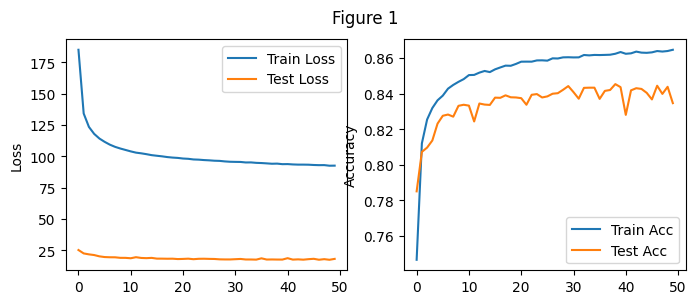

Total Time: 706.4495093822479


In [7]:
# 结果可视化
figplot(fignum=1,loss=[train_all_loss,test_all_loss],acc=[train_acc_all,test_acc_all])
print(f'Total Time: {end-begin}')